In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
import os



In [4]:
import numpy as np

def scrfft(xdata,ydata):
    sdata=np.argsort(xdata)
    xdatas=xdata[sdata]
    ydatas=ydata[sdata]
    
    
    xmin=np.min(xdata)
    xmax=np.max(xdata)
    ndata=len(xdata)
    x=(xmax-xmin)/(ndata-1)*np.arange(ndata)+xmin
    y=np.interp(x,xdatas,ydatas)
    
    yf = 2.0*np.fft.rfft(y)/(ndata+1)
    a=np.real(yf)
    b=-np.imag(yf)
    yf=0
    
    a[0]=0.5*a[0]
    
    f=np.arange(len(a))/(xmax-xmin)
    
    return(f, a, b)








In [6]:
# Read uploaded datasets
df1 = pd.read_csv("dataset1.csv")
df2 = pd.read_csv("dataset2.csv")


In [7]:
# Table 1 annual ticket revenues in EUR
REV_2021 = 998e6
REV_2022 = 1581e6
REV_2023 = 1539e6

## 3.1(B)

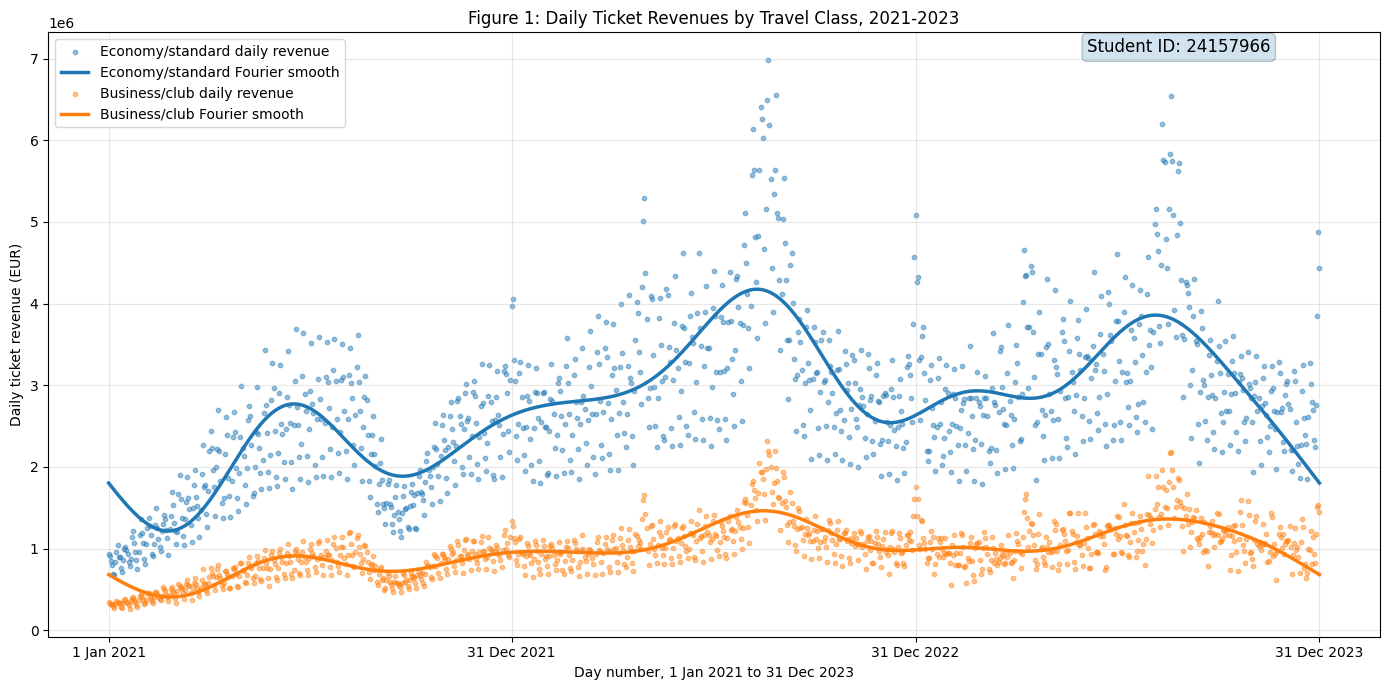

In [21]:
# 2021-2022 standard/economy daily revenue fractions
std_frac_21_22 = (
    df1["Fraction Revenue Dom STD"]
    + df1["Fraction Revenue Eur STD"]
    + df1["Fraction Revenue Int STD"]
)
# 2021-2022 business/club daily revenue fractions
bus_frac_21_22 = (
    df1["Fraction Revenue Dom BUS"]
    + df1["Fraction Revenue Eur BUS"]
    + df1["Fraction Revenue Int BUS"]
)

# Convert fractions to EUR
annual_revenues = np.array([REV_2021] * 365 + [REV_2022] * 365)

std_21_22 = std_frac_21_22.to_numpy() * annual_revenues
bus_21_22 = bus_frac_21_22.to_numpy() * annual_revenues

# 2023: estimate full-year daily revenue from representative sample
df2["Date"] = pd.to_datetime(df2["Date"])

economy_classes = ["Y", "M", "S"]
business_classes = ["J", "D"]


# 2023 standard/economy daily revenue 
std_2023_sample = (
    df2[df2["Class"].isin(economy_classes)]
    .groupby("Date")["Price"]
    .sum()
)
# 2023 business/club daily revenue 
bus_2023_sample = (
    df2[df2["Class"].isin(business_classes)]
    .groupby("Date")["Price"]
    .sum()
)

##Scale sample ticket revenue to total 2023 ticket revenue 
sample_total_ticket_revenue = df2["Price"].sum()
scale_factor = REV_2023 / sample_total_ticket_revenue

all_dates = pd.date_range(start="2023-01-01", end="2023-12-31")

std_2023 = (
    std_2023_sample.reindex(all_dates, fill_value=0).to_numpy() * scale_factor
)
bus_2023 = (
    bus_2023_sample.reindex(all_dates, fill_value=0).to_numpy() * scale_factor
)

# Combine 2021, 2022 and 2023: 1095 data points
std_revenue = np.concatenate([std_21_22, std_2023])
bus_revenue = np.concatenate([bus_21_22, bus_2023])

x = np.arange(1, 1096)

# Fourier smoothing using first 8 terms from scrfft.py
def fourier_smooth(xdata, ydata, terms=8):
    f, a, b = scrfft(xdata, ydata)
    y_smooth = np.zeros_like(xdata, dtype=float)

    for k in range(terms):
        y_smooth += (
            a[k] * np.cos(2 * np.pi * f[k] * xdata)
            + b[k] * np.sin(2 * np.pi * f[k] * xdata)
        )

    return y_smooth

std_smooth = fourier_smooth(x, std_revenue, terms=8)
bus_smooth = fourier_smooth(x, bus_revenue, terms=8)

# Create ONE panel with all four plots
plt.figure(figsize=(14, 7))

plt.scatter(x, std_revenue, s=10, alpha=0.45, label="Economy/standard daily revenue")
plt.plot(x, std_smooth, linewidth=2.5, label="Economy/standard Fourier smooth")

plt.scatter(x, bus_revenue, s=10, alpha=0.45, label="Business/club daily revenue")
plt.plot(x, bus_smooth, linewidth=2.5, label="Business/club Fourier smooth")

plt.xlabel("Day number, 1 Jan 2021 to 31 Dec 2023")
plt.ylabel("Daily ticket revenue (EUR)")
plt.title("Figure 1: Daily Ticket Revenues by Travel Class, 2021-2023")

plt.xticks(
    [1, 365, 730, 1095],
    ["1 Jan 2021", "31 Dec 2021", "31 Dec 2022", "31 Dec 2023"]
)

plt.legend()
plt.grid(True, alpha=0.3)

# Replace this with your actual student ID before submission
plt.text(
    0.78,
    0.99,
    "Student ID: 24157966",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.tight_layout()

# output_path = "/mnt/data/figure1_one_panel.png"
# plt.savefig(output_path, dpi=300, bbox_inches="tight")
# plt.show()

# output_path

## 3.1 (C)

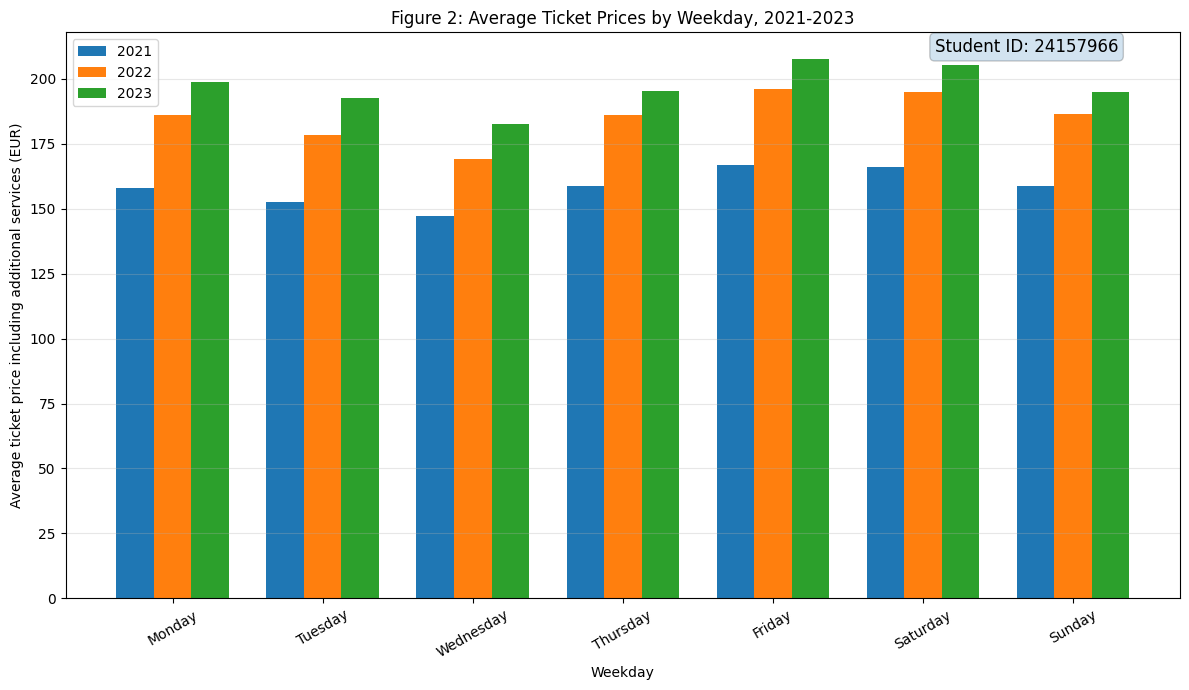

In [23]:
df1["Date"] = pd.to_datetime(df1["Date"])
df2["Date"] = pd.to_datetime(df2["Date"])

PAX = {2021: 6728e3, 2022: 9042e3}
REV = {2021: 998e6, 2022: 1581e6}

pax_cols = [c for c in df1.columns if c.startswith("Fraction Pax")]
rev_cols = [c for c in df1.columns if c.startswith("Fraction Revenue")]

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

averages = {}

#2021-2022: Avg Revenue by weekday
for year in [2021, 2022]:
    d = df1[df1["Date"].dt.year == year].copy()
    d["Daily_Pax"] = d[pax_cols].sum(axis=1) * PAX[year]
    d["Daily_Revenue_Including_AS"] = d[rev_cols].sum(axis=1) * REV[year] + d["AS revenue"]
    d["Weekday"] = d["Date"].dt.day_name()

    averages[year] = (
        d.groupby("Weekday")["Daily_Revenue_Including_AS"].sum()
        / d.groupby("Weekday")["Daily_Pax"].sum()
    ).reindex(weekday_order)

# 2023: Avg Revenue by weekday
df2["Weekday"] = df2["Date"].dt.day_name()
df2["Price_Including_AS"] = df2["Price"] + df2["Extra"]
averages[2023] = df2.groupby("Weekday")["Price_Including_AS"].mean().reindex(weekday_order)

x = np.arange(len(weekday_order))
width = 0.25

plt.figure(figsize=(12, 7))
plt.bar(x - width, averages[2021], width, label="2021")
plt.bar(x, averages[2022], width, label="2022")
plt.bar(x + width, averages[2023], width, label="2023")

plt.xlabel("Weekday")
plt.ylabel("Average ticket price including additional services (EUR)")
plt.title("Figure 2: Average Ticket Prices by Weekday, 2021-2023")
plt.xticks(x, weekday_order, rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.text(
    0.78,
    0.99,
    "Student ID: 24157966",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.tight_layout()

## 3.2

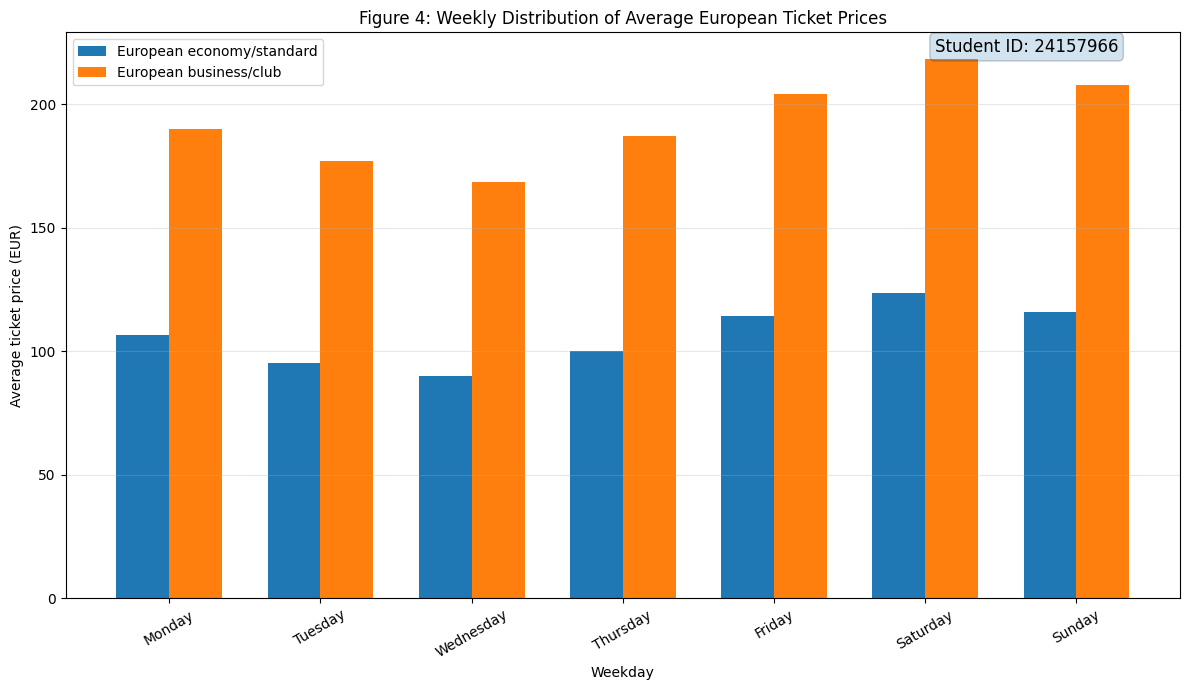

Additional services revenue fractions
X (2021): 0.0724
Y (2022): 0.0664
Z (2023): 0.1233


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




# ---------------------------------------------------
# FIGURE 4
# Weekly average ticket prices:
# European Economy vs European Business
# ---------------------------------------------------

# Keep only European journeys
eur = df2[df2["Region"].isin(["Eur", "Con"])].copy()

# Ticket classes
economy_classes = ["Y", "M", "S"]
business_classes = ["J", "D"]

# Weekday names
eur["Weekday"] = eur["Date"].dt.day_name()

# Monday -> Sunday order
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Economy European journeys
eur_economy = eur[eur["Class"].isin(economy_classes)]

avg_eur_economy = (
    eur_economy.groupby("Weekday")["Price"]
    .mean()
    .reindex(weekday_order)
)

# Business European journeys
eur_business = eur[eur["Class"].isin(business_classes)]

avg_eur_business = (
    eur_business.groupby("Weekday")["Price"]
    .mean()
    .reindex(weekday_order)
)

# Plot
x = np.arange(len(weekday_order))
width = 0.35

plt.figure(figsize=(12, 7))

plt.bar(
    x - width/2,
    avg_eur_economy,
    width,
    label="European economy/standard"
)

plt.bar(
    x + width/2,
    avg_eur_business,
    width,
    label="European business/club"
)

plt.xlabel("Weekday")
plt.ylabel("Average ticket price (EUR)")
plt.title("Figure 4: Weekly Distribution of Average European Ticket Prices")

plt.xticks(x, weekday_order, rotation=30)

plt.legend()

plt.grid(axis="y", alpha=0.3)

# Student ID placeholder
plt.text(
    0.78,
    0.99,
    "Student ID: 24157966",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.tight_layout()

# figure_path = "/mnt/data/figure4_european_prices.png"
# plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

# ---------------------------------------------------
# ADDITIONAL SERVICES REVENUE FRACTIONS
# ---------------------------------------------------

# Annual ticket revenues from assignment
REV_2021 = 998e6
REV_2022 = 1581e6
REV_2023 = 1539e6

# 2021 additional services revenue
as_2021 = df1[df1["Date"].dt.year == 2021]["AS revenue"].sum()

# 2022 additional services revenue
as_2022 = df1[df1["Date"].dt.year == 2022]["AS revenue"].sum()

# 2023 additional services revenue from sample
# Scale representative sample extras
sample_extra_total = df2["Extra"].sum()
sample_ticket_total = df2["Price"].sum()

scale_factor = REV_2023 / sample_ticket_total

as_2023 = sample_extra_total * scale_factor

# Fractions
X = as_2021 / REV_2021
Y = as_2022 / REV_2022
Z = as_2023 / REV_2023

print("Additional services revenue fractions")
print(f"X (2021): {X:.4f}")
print(f"Y (2022): {Y:.4f}")
print(f"Z (2023): {Z:.4f}")

# figure_path
